In [1]:
import pandas as pd
import numpy as np
import datetime

# Lab6

# 目標：groupby、corr、plt

# 預處理

## 請參考lab5爬取資料

### 請把date的資料型態更改為datetime，closing_price資料型態更改為float64

In [13]:
#參考lab5
data = pd.read_csv('./data_science_data2024.csv',index_col=0)
#提取資料
data = data[['date','證券名稱','收盤價']]
#更改名字
data = data.rename(columns = {'證券名稱':'name'})
data = data.rename(columns = {'收盤價':'closing_price'})
#清理資料
data['closing_price'] = data['closing_price'].replace({'\$':'', ',':'', '--':np.nan}, regex=True)
data = data.dropna()
#更改資料型態
data['closing_price'] = data['closing_price'].astype('float64')
data['date'] = pd.to_datetime(data['date'])

In [14]:
data.head(100)

,date,name,closing_price
0,2024-01-02,元大台灣50,134.90
1,2024-01-02,元大中型100,73.45
2,2024-01-02,富邦科技,128.45
3,2024-01-02,元大電子,71.25
4,2024-01-02,元大MSCI金融,24.13
...,...,...,...
97,2024-01-02,中信中國50正2,7.11
98,2024-01-02,統一FANG+,64.75
99,2024-01-02,元大全球AI,49.81
100,2024-01-02,期街口道瓊銅,23.98


In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 295867 entries, 0 to 298920
Data columns (total 3 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   date           295867 non-null  datetime64[ns]
 1   name           295867 non-null  object        
 2   closing_price  295867 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 9.0+ MB


In [16]:
data.describe()

,date,closing_price
count,295867,295867.000000
mean,2024-07-06 18:59:35.165868288,86.529270
min,2024-01-02 00:00:00,1.130000
25%,2024-04-09 00:00:00,20.500000
50%,2024-07-09 00:00:00,38.950000
75%,2024-10-07 00:00:00,79.600000
max,2024-12-31 00:00:00,4430.000000
std,NaN,193.953399


## pd.groupby

對數據進行分組計算 (例如依不同區域/性別/年齡等進行不同群體分析)

In [17]:
data_group = data.groupby('name')

### get_group 提取資料

In [18]:
data_group.get_group('元大台灣50')

,date,name,closing_price
0,2024-01-02,元大台灣50,134.90
1222,2024-01-03,元大台灣50,132.55
2444,2024-01-04,元大台灣50,132.50
3666,2024-01-05,元大台灣50,132.15
4888,2024-01-08,元大台灣50,132.75
...,...,...,...
292554,2024-12-25,元大台灣50,198.40
293827,2024-12-26,元大台灣50,198.25
295100,2024-12-27,元大台灣50,198.90
296373,2024-12-30,元大台灣50,197.80


In [19]:
data_group.get_group('富邦金')

,date,name,closing_price
674,2024-01-02,富邦金,64.6
1896,2024-01-03,富邦金,63.7
3118,2024-01-04,富邦金,63.5
4340,2024-01-05,富邦金,63.2
5562,2024-01-08,富邦金,64.1
...,...,...,...
293246,2024-12-25,富邦金,91.5
294519,2024-12-26,富邦金,91.3
295792,2024-12-27,富邦金,91.8
297066,2024-12-30,富邦金,91.3


In [20]:
for (name, group) in data_group:
    print(name)
    print(group)

ABC-KY
             date    name  closing_price
1063   2024-01-02  ABC-KY          25.40
2285   2024-01-03  ABC-KY          26.30
3507   2024-01-04  ABC-KY          25.55
4729   2024-01-05  ABC-KY          25.35
5951   2024-01-08  ABC-KY          25.00
...           ...     ...            ...
293642 2024-12-25  ABC-KY          20.10
294915 2024-12-26  ABC-KY          20.55
296188 2024-12-27  ABC-KY          20.55
297462 2024-12-30  ABC-KY          20.15
298736 2024-12-31  ABC-KY          20.15

[240 rows x 3 columns]
AES-KY
             date    name  closing_price
1095   2024-01-02  AES-KY          713.0
2317   2024-01-03  AES-KY          688.0
3539   2024-01-04  AES-KY          680.0
4761   2024-01-05  AES-KY          670.0
5983   2024-01-08  AES-KY          689.0
...           ...     ...            ...
293675 2024-12-25  AES-KY         1075.0
294948 2024-12-26  AES-KY         1180.0
296221 2024-12-27  AES-KY         1140.0
297495 2024-12-30  AES-KY         1125.0
298769 2024-12-31  

             date     name  closing_price
182    2024-01-02  元大IC設計N           7.38
1404   2024-01-03  元大IC設計N           7.28
2626   2024-01-04  元大IC設計N           7.23
3848   2024-01-05  元大IC設計N           7.31
5070   2024-01-08  元大IC設計N           7.32
...           ...      ...            ...
292755 2024-12-25  元大IC設計N           8.05
294028 2024-12-26  元大IC設計N           8.12
295301 2024-12-27  元大IC設計N           8.16
296574 2024-12-30  元大IC設計N           8.04
297848 2024-12-31  元大IC設計N           8.10

[240 rows x 3 columns]
元大MSCI A股
             date       name  closing_price
95     2024-01-02  元大MSCI A股          19.61
1317   2024-01-03  元大MSCI A股          19.57
2539   2024-01-04  元大MSCI A股          19.38
3761   2024-01-05  元大MSCI A股          19.39
4983   2024-01-08  元大MSCI A股          19.07
...           ...        ...            ...
292649 2024-12-25  元大MSCI A股          22.99
293922 2024-12-26  元大MSCI A股          23.11
295195 2024-12-27  元大MSCI A股          23.12
296468 2024-12-30  元大M

宏洲
             date name  closing_price
244    2024-01-02   宏洲           8.52
1466   2024-01-03   宏洲           8.50
2688   2024-01-04   宏洲           8.46
3910   2024-01-05   宏洲           8.37
5132   2024-01-08   宏洲           8.45
...           ...  ...            ...
292817 2024-12-25   宏洲          10.85
294090 2024-12-26   宏洲          10.75
295363 2024-12-27   宏洲          10.80
296636 2024-12-30   宏洲          10.90
297910 2024-12-31   宏洲          10.90

[240 rows x 3 columns]
宏璟
             date name  closing_price
601    2024-01-02   宏璟          27.65
1823   2024-01-03   宏璟          27.40
3045   2024-01-04   宏璟          27.30
4267   2024-01-05   宏璟          27.30
5489   2024-01-08   宏璟          27.35
...           ...  ...            ...
293171 2024-12-25   宏璟          38.10
294444 2024-12-26   宏璟          37.80
295717 2024-12-27   宏璟          37.60
296991 2024-12-30   宏璟          38.75
298265 2024-12-31   宏璟          37.90

[240 rows x 3 columns]
宏益
             date name  closing

新光鋼
             date name  closing_price
413    2024-01-02  新光鋼          57.30
1635   2024-01-03  新光鋼          56.40
2857   2024-01-04  新光鋼          56.60
4079   2024-01-05  新光鋼          57.50
5301   2024-01-08  新光鋼          56.60
...           ...  ...            ...
292985 2024-12-25  新光鋼          45.85
294258 2024-12-26  新光鋼          46.55
295531 2024-12-27  新光鋼          46.15
296805 2024-12-30  新光鋼          46.30
298079 2024-12-31  新光鋼          46.20

[240 rows x 3 columns]
新唐
             date name  closing_price
908    2024-01-02   新唐          141.5
2130   2024-01-03   新唐          142.0
3352   2024-01-04   新唐          141.0
4574   2024-01-05   新唐          139.5
5796   2024-01-08   新唐          138.0
...           ...  ...            ...
293484 2024-12-25   新唐           90.6
294757 2024-12-26   新唐           90.1
296030 2024-12-27   新唐           90.8
297304 2024-12-30   新唐           89.5
298578 2024-12-31   新唐           89.0

[240 rows x 3 columns]
新天地
             date name  closi

             date name  closing_price
811    2024-01-02   柏騰          35.75
2033   2024-01-03   柏騰          36.25
3255   2024-01-04   柏騰          36.50
4477   2024-01-05   柏騰          36.05
5699   2024-01-08   柏騰          36.95
...           ...  ...            ...
293385 2024-12-25   柏騰          25.85
294658 2024-12-26   柏騰          26.15
295931 2024-12-27   柏騰          25.70
297205 2024-12-30   柏騰          25.50
298479 2024-12-31   柏騰          25.40

[240 rows x 3 columns]
根基
             date name  closing_price
614    2024-01-02   根基           79.9
1836   2024-01-03   根基           79.3
3058   2024-01-04   根基           79.6
4280   2024-01-05   根基           80.3
5502   2024-01-08   根基           79.3
...           ...  ...            ...
293184 2024-12-25   根基           70.9
294457 2024-12-26   根基           70.1
295730 2024-12-27   根基           70.0
297004 2024-12-30   根基           70.4
298278 2024-12-31   根基           69.2

[240 rows x 3 columns]
桂盟
             date name  closing_pr

             date  name  closing_price
24118  2024-01-29  玖鼎電力           73.1
25344  2024-01-30  玖鼎電力           69.8
26570  2024-01-31  玖鼎電力           67.5
27796  2024-02-01  玖鼎電力           70.8
29022  2024-02-02  玖鼎電力           69.0
...           ...   ...            ...
293465 2024-12-25  玖鼎電力           80.3
294738 2024-12-26  玖鼎電力           80.4
296011 2024-12-27  玖鼎電力           81.9
297285 2024-12-30  玖鼎電力           81.2
298559 2024-12-31  玖鼎電力           81.4

[221 rows x 3 columns]
現觀科
             date name  closing_price
12110  2024-01-15  現觀科          186.0
13332  2024-01-16  現觀科          176.0
14554  2024-01-17  現觀科          164.5
15776  2024-01-18  現觀科          170.0
16998  2024-01-19  現觀科          166.5
...           ...  ...            ...
293700 2024-12-25  現觀科          147.0
294973 2024-12-26  現觀科          146.0
296246 2024-12-27  現觀科          146.0
297520 2024-12-30  現觀科          145.0
298794 2024-12-31  現觀科          146.0

[231 rows x 3 columns]
瑞儀
             date nam

             date name  closing_price
289    2024-01-02   聚陽          345.0
1511   2024-01-03   聚陽          349.0
2733   2024-01-04   聚陽          356.5
3955   2024-01-05   聚陽          354.5
5177   2024-01-08   聚陽          358.0
...           ...  ...            ...
292862 2024-12-25   聚陽          314.0
294135 2024-12-26   聚陽          314.0
295408 2024-12-27   聚陽          314.5
296681 2024-12-30   聚陽          315.5
297955 2024-12-31   聚陽          321.0

[240 rows x 3 columns]
聚隆
             date name  closing_price
279    2024-01-02   聚隆          13.60
1501   2024-01-03   聚隆          14.95
2723   2024-01-04   聚隆          14.70
3945   2024-01-05   聚隆          14.10
5167   2024-01-08   聚隆          13.90
...           ...  ...            ...
292852 2024-12-25   聚隆          12.15
294125 2024-12-26   聚隆          12.05
295398 2024-12-27   聚隆          11.95
296671 2024-12-30   聚隆          11.95
297945 2024-12-31   聚隆          11.65

[240 rows x 3 columns]
聚鼎
             date name  closing_pr

             date name  closing_price
568    2024-01-02   資通           55.4
1790   2024-01-03   資通           55.3
3012   2024-01-04   資通           54.2
4234   2024-01-05   資通           54.0
5456   2024-01-08   資通           54.8
...           ...  ...            ...
293138 2024-12-25   資通           55.5
294411 2024-12-26   資通           54.4
295684 2024-12-27   資通           53.8
296958 2024-12-30   資通           52.4
298232 2024-12-31   資通           53.5

[240 rows x 3 columns]
超豐
             date name  closing_price
547    2024-01-02   超豐           60.6
1769   2024-01-03   超豐           60.2
2991   2024-01-04   超豐           59.9
4213   2024-01-05   超豐           59.2
5435   2024-01-08   超豐           59.0
...           ...  ...            ...
293118 2024-12-25   超豐           59.6
294391 2024-12-26   超豐           59.6
295664 2024-12-27   超豐           59.0
296938 2024-12-30   超豐           59.0
298212 2024-12-31   超豐           58.7

[240 rows x 3 columns]
越南控-DR
             date    name  clo

### 以組進行計算資料筆數總量 (.count)

In [21]:
data_group.count().head(10)

,date,closing_price
name,,
ABC-KY,240,240
AES-KY,240,240
AMAX-KY,240,240
FT潔淨能源,240,240
FT臺灣Smart,240,240
FT臺灣永續高息,55,55
GIS-KY,240,240
GOGOLOOK-創,212,212
IKKA-KY,240,240


### 以組進行計算每一組別的總和、平均等統計資訊 (.sum , .mean)

In [22]:
data_group.closing_price.sum().head(10)

name
ABC-KY          5501.95
AES-KY        156013.50
AMAX-KY        66240.00
FT潔淨能源          3952.74
FT臺灣Smart       3095.73
FT臺灣永續高息         529.43
GIS-KY         14370.20
GOGOLOOK-創     32048.50
IKKA-KY        23837.30
ITH-KY          1380.40
Name: closing_price, dtype: float64

In [35]:
data_group.closing_price.mean().head(10)

name
ABC-KY         22.924792
AES-KY        650.056250
AMAX-KY       276.000000
FT潔淨能源         16.469750
FT臺灣Smart      12.898875
FT臺灣永續高息        9.626000
GIS-KY         59.875833
GOGOLOOK-創    151.172170
IKKA-KY        99.322083
ITH-KY         53.092308
Name: closing_price, dtype: float64

### 針對特定組別進行分析 (.get_group)

In [36]:
data_group.get_group('中信金').closing_price.mean()

np.float64(34.429375)

In [37]:
data[data['name']=='中信金'].closing_price.mean()

np.float64(34.429375)

In [38]:
data_group.get_group('國泰金').closing_price.mean()

np.float64(57.895833333333336)

In [39]:
data[data['name']=='國泰金'].closing_price.mean()

np.float64(57.895833333333336)

### 以組進行describe()

In [40]:
data_group.closing_price.describe().head()

,count,mean,std,min,25%,50%,75%,max
name,,,,,,,,
ABC-KY,240.0,22.924792,2.744462,19.55,21.3000,22.450,23.3500,33.60
AES-KY,240.0,650.056250,145.435430,456.50,538.7500,632.000,693.5000,1180.00
AMAX-KY,240.0,276.000000,52.306087,201.50,231.0000,256.500,333.0000,385.00
FT潔淨能源,240.0,16.469750,1.186169,13.54,16.0675,16.630,17.1525,19.16
FT臺灣Smart,240.0,12.898875,1.176138,10.14,12.3200,13.185,13.7825,15.55


## corr 相關係數

### 0.1 <= |ans| <0.3 相關度:低
### 0.3 <= |ans| <0.5 相關度:中
### 0.5 <= |ans| <1.0 相關度:高

In [41]:
#提出中信金與國泰金資料
data_CH = data[data['name']=='中信金'].reset_index(drop=True)
data_KT = data[data['name']=='國泰金'].reset_index(drop=True)

In [42]:
data_CH.head()

,date,name,closing_price
0,2024-01-02,中信金,28.35
1,2024-01-03,中信金,28.20
2,2024-01-04,中信金,28.15
3,2024-01-05,中信金,28.10
4,2024-01-08,中信金,28.40


In [43]:
data_CH.count()

date             240
name             240
closing_price    240
dtype: int64

In [44]:
data_KT.head()

,date,name,closing_price
0,2024-01-02,國泰金,45.50
1,2024-01-03,國泰金,44.95
2,2024-01-04,國泰金,44.70
3,2024-01-05,國泰金,44.85
4,2024-01-08,國泰金,45.10


In [45]:
data_KT.count()

date             240
name             240
closing_price    240
dtype: int64

In [46]:
data_CH['closing_price'].corr(data_KT['closing_price']) ## 計算兩支股票的相關係數

np.float64(0.8009643623014743)

### 計算所有公司與中信金的相關度

In [47]:
#需15秒

#製作一個新的dataframe，可以儲存與中信金進行相關度分析的資料
data_CH_corr_company = pd.DataFrame()
#製作所有上市公司的list，方法 : 將data的name這個columns刪除重複項即可
companies = data['name'].drop_duplicates()
data_CH_corr_company['company'] = companies
data_CH_corr_company['corr'] = 0

#使用apply遍歷所有公司與中信金相關度的分析
def get_corr(x):
    data_company = data[data['name']==x].reset_index(drop=True)
    return data_CH['closing_price'].corr(data_company['closing_price'])

data_CH_corr_company['corr'] = data_CH_corr_company['company'].apply(get_corr)

In [48]:
#排序過後的相關度dataframe
data_CH_corr_company.sort_values('corr',ascending = False)

,company,corr
695,中信金,1.000000
684,元大金,0.954565
183,元大金融配息N,0.930014
670,第一保,0.929039
815,嘉澤,0.911193
...,...,...
76,期元大S&P日圓正2,-0.865552
47,國泰臺灣加權反1,-0.867338
58,富邦臺灣加權反1,-0.869461
66,群益臺灣加權反1,-0.879206


In [49]:
#絕對值並排續後的相關度dataframe
data_CH_corr_company['corr'] = data_CH_corr_company['corr'].abs()
data_CH_corr_company.sort_values('corr',ascending = False)

,company,corr
695,中信金,1.000000
684,元大金,0.954565
183,元大金融配息N,0.930014
670,第一保,0.929039
185255,日盛台駿,0.911301
...,...,...
298,利奇,0.004768
762,夆典,0.004489
1012,力成,0.004181
192,幸福,0.000873


# matplotlib.pyplot

In [50]:
import matplotlib.pyplot as plt

In [51]:
#將中信金與國泰金merge起來，請參考lab5
data_CH_KT = pd.merge(data_CH[['date','closing_price']],data_KT[['date','closing_price']],on='date',suffixes=('_CH', '_KT')).set_index('date')

In [52]:
data_CH_KT

,closing_price_CH,closing_price_KT
date,,
2024-01-02,28.35,45.50
2024-01-03,28.20,44.95
2024-01-04,28.15,44.70
2024-01-05,28.10,44.85
2024-01-08,28.40,45.10
...,...,...
2024-12-25,39.25,68.70
2024-12-26,39.45,68.70
2024-12-27,39.45,69.30


## plt.plot

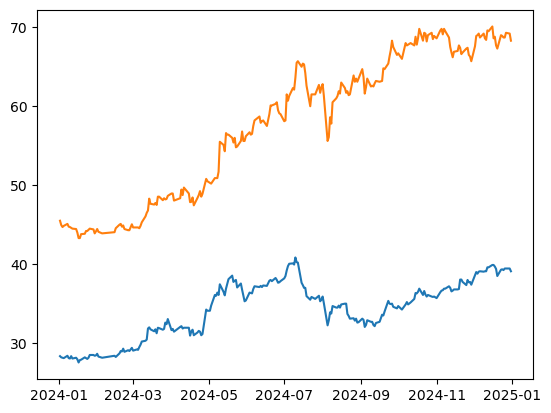

In [53]:
plt.plot(data_CH_KT['closing_price_CH'],label='CH')
plt.plot(data_CH_KT['closing_price_KT'],label='KT')
plt.show()

### 設定坐標軸與標題名稱

### xlabel、ylabe、title

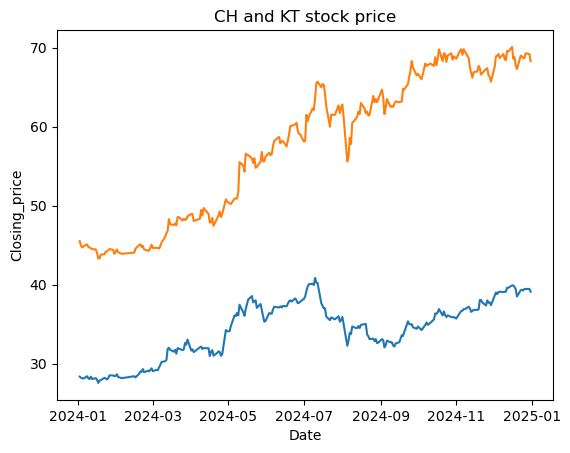

In [54]:
plt.plot(data_CH_KT['closing_price_CH'],label='CH')
plt.plot(data_CH_KT['closing_price_KT'],label='KT')
#x坐標軸
plt.xlabel("Date")
#y坐標軸
plt.ylabel("Closing_price")
#標題
plt.title("CH and KT stock price")
plt.show()

### 設定大小

### figure(figsize(x,y))

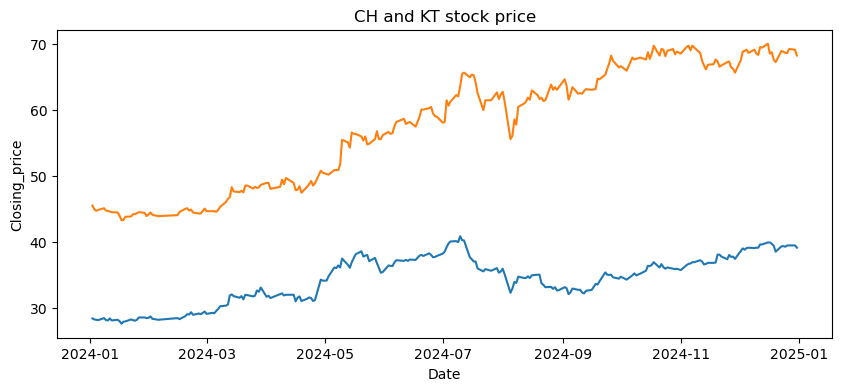

In [55]:
#設定大小
plt.figure(figsize=(10,4))
plt.plot(data_CH_KT['closing_price_CH'],label='CH')
plt.plot(data_CH_KT['closing_price_KT'],label='KT')
plt.xlabel("Date")
plt.ylabel("Closing_price")
plt.title("CH and KT stock price")
plt.show()

### 設定坐標軸刻度

### xticks、yticks

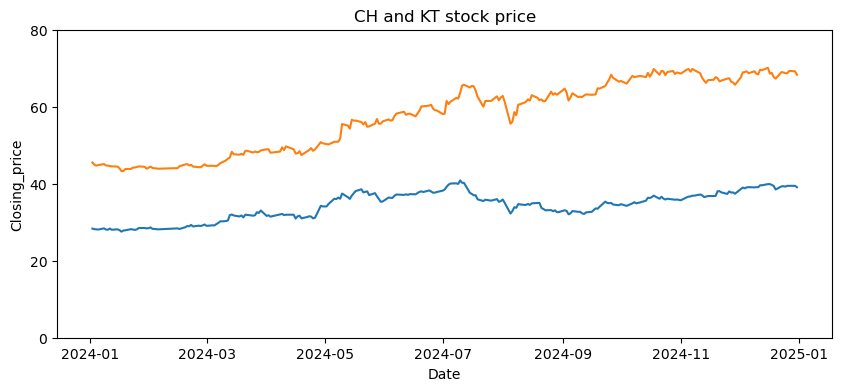

In [56]:
plt.figure(figsize=(10,4))
plt.plot(data_CH_KT['closing_price_CH'],label='CH')
plt.plot(data_CH_KT['closing_price_KT'],label='KT')
#設定刻度
plt.yticks(np.arange(0, 100, 20))
plt.xlabel("Date")
plt.ylabel("Closing_price")
plt.title("CH and KT stock price")
plt.show()

### 設定圖例

### legend()

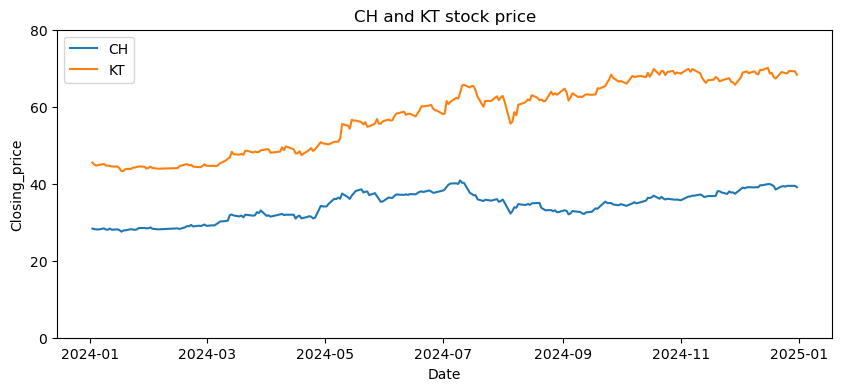

In [57]:
plt.figure(figsize=(10,4))
plt.plot(data_CH_KT['closing_price_CH'],label='CH')
plt.plot(data_CH_KT['closing_price_KT'],label='KT')
plt.legend(loc='best')
plt.yticks(np.arange(0, 100, 20))
plt.xlabel("Date")
plt.ylabel("Closing_price")
plt.title("CH and KT stock price")
plt.show()

### 設定顏色

### color

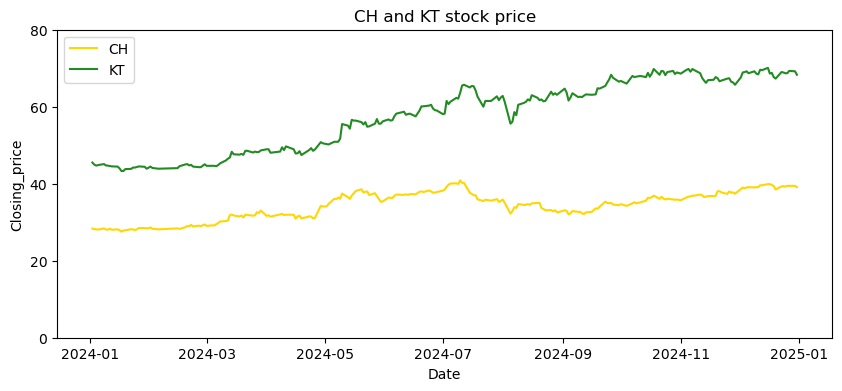

In [58]:
plt.figure(figsize=(10,4))
plt.plot(data_CH_KT['closing_price_CH'],label='CH',color='gold')
plt.plot(data_CH_KT['closing_price_KT'],label='KT',color='forestgreen')
plt.legend(loc='best')
plt.yticks(np.arange(0, 100, 20))
plt.xlabel("Date")
plt.ylabel("Closing_price")
plt.title("CH and KT stock price")
plt.show()

##### 作業四 (due 4/21/2026)


## 1. 題目一: 請繪製台積電在2025年的收盤價及開盤價的趨勢圖。

## 2. 題目二:請分析2025/1/1-2025/12/31期間與台積電絕對值相關度排行第5名的股票是哪一支股票？劃出這兩支股票的股價圖表 (圖表必須包含圖例、座標軸名稱、標題、大小為(7,7))